<a href="https://colab.research.google.com/github/vinaygadde2020/House-Price-Prediction/blob/main/House_Price_Prediction_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏠 House Price Prediction Using Machine Learning Algorithms and Data Analysis Techniques



### Step 1: Import Libraries

In [ ]:
# ── Standard Libraries ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Machine Learning ─────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── XGBoost ──────────────────────────────────────────────────────────────────
try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
    print("✅ XGBoost loaded successfully")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️ XGBoost not found. Run: !pip install xgboost")

# ── Model Persistence ─────────────────────────────────────────────────────────
import pickle
import joblib

# ── Plotting Configuration ────────────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('husl')

print("✅ All libraries imported successfully.")


✅ XGBoost loaded successfully
✅ All libraries imported successfully.


### Step 2: Load Dataset

In [ ]:
# Import required library
import pandas as pd

# Load dataset
df = pd.read_csv('/content/Housing.csv')  # Change path if needed

print("✅ Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

# Display first 5 rows
df.head()


✅ Dataset loaded successfully!
Shape: 545 rows × 13 columns


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


**Explanation:** `pd.read_csv()` loads the CSV file into a Pandas DataFrame. The shape confirms the dataset has 545 observations and 13 features.

### Step 3: Display First and Last Rows

In [ ]:
# ── First 5 rows ─────────────────────────────────────────────────────────────
print("=" * 60)
print("FIRST 5 ROWS")
print("=" * 60)
display(df.head())

# ── Last 5 rows ──────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("LAST 5 ROWS")
print("=" * 60)
display(df.tail())


FIRST 5 ROWS


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished



LAST 5 ROWS


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


### Step 4: Dataset Shape & Information

In [ ]:
# ── Shape ────────────────────────────────────────────────────────────────────
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

# ── Info ──────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("DATASET INFO")
print("=" * 60)
df.info()


Rows    : 545
Columns : 13

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


### Step 5: Statistical Summary

In [ ]:
# ── Descriptive statistics for numeric columns ───────────────────────────────
print("NUMERICAL FEATURES – STATISTICAL SUMMARY")
display(df.describe().T.style.background_gradient(cmap='Blues'))


NUMERICAL FEATURES – STATISTICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
price,545.000000,4766729.247706,1870439.615657,1750000.000000,3430000.000000,4340000.000000,5740000.000000,13300000.000000
area,545.000000,5150.541284,2170.141023,1650.000000,3600.000000,4600.000000,6360.000000,16200.000000
bedrooms,545.000000,2.965138,0.738064,1.000000,2.000000,3.000000,3.000000,6.000000
bathrooms,545.000000,1.286239,0.502470,1.000000,1.000000,1.000000,2.000000,4.000000
stories,545.000000,1.805505,0.867492,1.000000,1.000000,2.000000,2.000000,4.000000
parking,545.000000,0.693578,0.861586,0.000000,0.000000,0.000000,1.000000,3.000000


### Step 6: Missing Value Analysis

In [ ]:
# ── Check for missing values ──────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})

print("MISSING VALUE ANALYSIS")
print("=" * 40)
display(missing_df)

if missing.sum() == 0:
    print("\n✅ No missing values found. Dataset is complete.")
else:
    print(f"\n⚠️ Total missing values: {missing.sum()}")


MISSING VALUE ANALYSIS


,Missing Count,Missing %
price,0,0.0
area,0,0.0
bedrooms,0,0.0
bathrooms,0,0.0
stories,0,0.0
mainroad,0,0.0
guestroom,0,0.0
basement,0,0.0
hotwaterheating,0,0.0
airconditioning,0,0.0



✅ No missing values found. Dataset is complete.


### Step 7: Duplicate Value Check

In [ ]:
# ── Check for duplicate rows ──────────────────────────────────────────────────
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"✅ Duplicates removed. New shape: {df.shape}")
else:
    print("✅ No duplicate rows found.")


Number of duplicate rows: 0
✅ No duplicate rows found.


### Step 8: Encode Categorical Variables

In [ ]:
# ── Identify categorical columns ─────────────────────────────────────────────
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {cat_cols}")
print()

# ── Display unique values for each categorical column ─────────────────────────
for col in cat_cols:
    print(f"{col}: {df[col].unique()}")


Categorical columns: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

mainroad: ['yes' 'no']
guestroom: ['no' 'yes']
basement: ['no' 'yes']
hotwaterheating: ['no' 'yes']
airconditioning: ['yes' 'no']
prefarea: ['yes' 'no']
furnishingstatus: ['furnished' 'semi-furnished' 'unfurnished']


In [ ]:
# ── Label Encoding for binary yes/no columns ─────────────────────────────────
df_encoded = df.copy()
le = LabelEncoder()

binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
               'airconditioning', 'prefarea']

for col in binary_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])
    print(f"  {col}: {df[col].unique()} → {df_encoded[col].unique()}")

# ── One-Hot Encoding for furnishingstatus (3 categories) ─────────────────────
df_encoded = pd.get_dummies(df_encoded, columns=['furnishingstatus'], drop_first=True)

print(f"\n✅ Encoding complete. New shape: {df_encoded.shape}")
print(f"New columns added: {[c for c in df_encoded.columns if 'furnishing' in c]}")


  mainroad: ['yes' 'no'] → [1 0]
  guestroom: ['no' 'yes'] → [0 1]
  basement: ['no' 'yes'] → [0 1]
  hotwaterheating: ['no' 'yes'] → [0 1]
  airconditioning: ['yes' 'no'] → [1 0]
  prefarea: ['yes' 'no'] → [1 0]

✅ Encoding complete. New shape: (545, 14)
New columns added: ['furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


### Step 9: Outlier Detection

In [ ]:
# ── Outlier Detection using IQR Method ───────────────────────────────────────
numerical_cols = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

print("OUTLIER ANALYSIS (IQR Method)")
print("=" * 50)

outlier_summary = []
for col in numerical_cols:
    Q1 = df_encoded[col].quantile(0.25)
    Q3 = df_encoded[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df_encoded[col] < lower) | (df_encoded[col] > upper)).sum()
    outlier_summary.append({'Feature': col, 'Q1': Q1, 'Q3': Q3,
                            'IQR': IQR, 'Lower Bound': lower,
                            'Upper Bound': upper, 'Outliers': n_outliers})

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)


OUTLIER ANALYSIS (IQR Method)


,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers
0,price,3430000.0,5740000.0,2310000.0,-35000.0,9205000.0,15
1,area,3600.0,6360.0,2760.0,-540.0,10500.0,12
2,bedrooms,2.0,3.0,1.0,0.5,4.5,12
3,bathrooms,1.0,2.0,1.0,-0.5,3.5,1
4,stories,1.0,2.0,1.0,-0.5,3.5,41
5,parking,0.0,1.0,1.0,-1.5,2.5,12


### Step 10: Feature Scaling

In [ ]:
# ── Define features (X) and target (y) ───────────────────────────────────────
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

print(f"Feature matrix X shape: {X.shape}")
print(f"Target vector y shape:  {y.shape}")
print(f"\nFeatures used:\n{X.columns.tolist()}")


Feature matrix X shape: (545, 13)
Target vector y shape:  (545,)

Features used:
['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


In [ ]:
# ── Train/Test Split ──────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")

# ── Standard Scaling ─────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\n✅ Feature scaling applied (StandardScaler).")
print("Mean of scaled training features:", X_train_scaled.mean(axis=0).round(4)[:5], "...")


Training set : 436 samples
Test set     : 109 samples

✅ Feature scaling applied (StandardScaler).
Mean of scaled training features: [0. 0. 0. 0. 0.] ...


### Step 11: Correlation Analysis

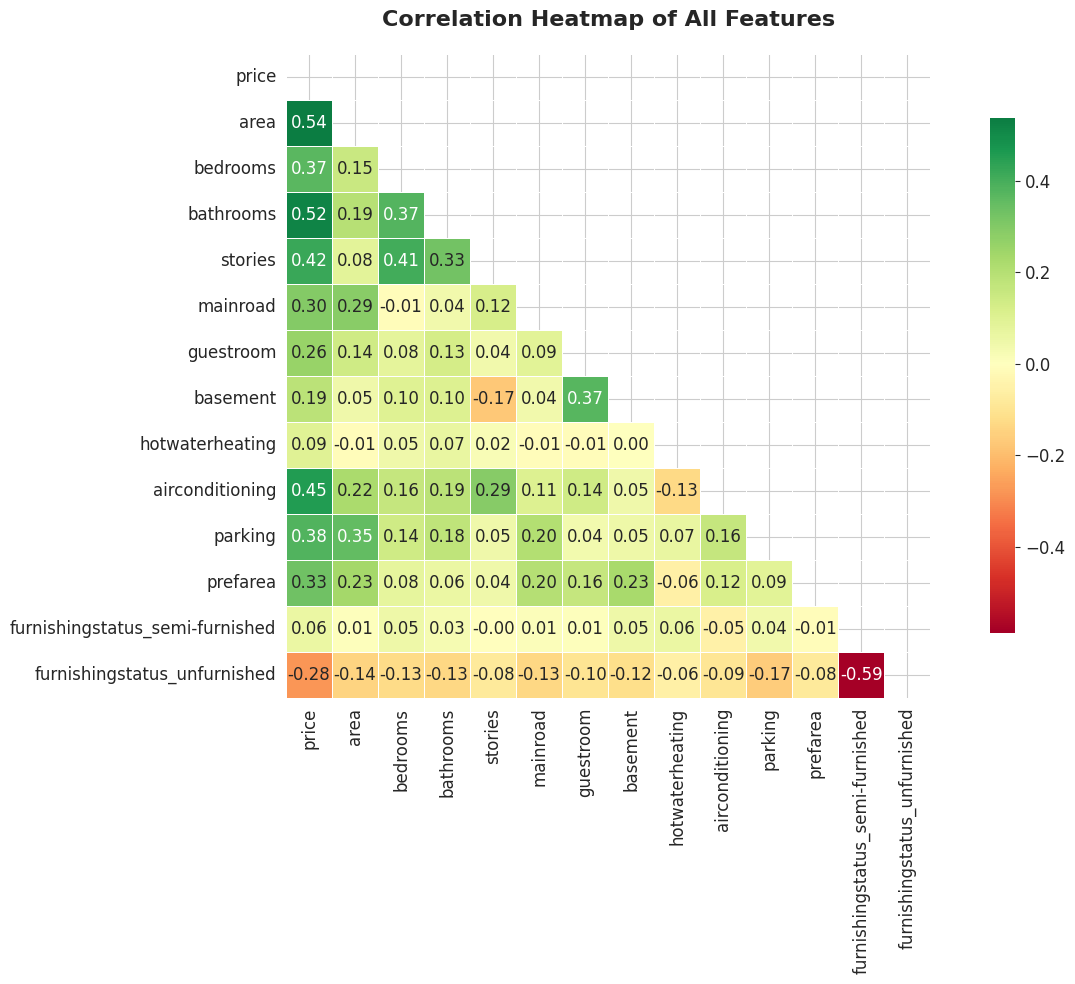


Correlation with House Price (Sorted):
price                              1.000000
area                               0.535997
bathrooms                          0.517545
airconditioning                    0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea                           0.329777
mainroad                           0.296898
guestroom                          0.255517
basement                           0.187057
hotwaterheating                    0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587


In [ ]:
# ── Correlation Matrix ────────────────────────────────────────────────────────
corr_matrix = df_encoded.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, square=True,
    linewidths=0.5, cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap of All Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# ── Correlation with target ───────────────────────────────────────────────────
print("\nCorrelation with House Price (Sorted):")
print(corr_matrix['price'].sort_values(ascending=False).to_string())


## 📈 Section 12 : Exploratory Data Analysis (EDA)

### 12.1 Distribution of House Prices

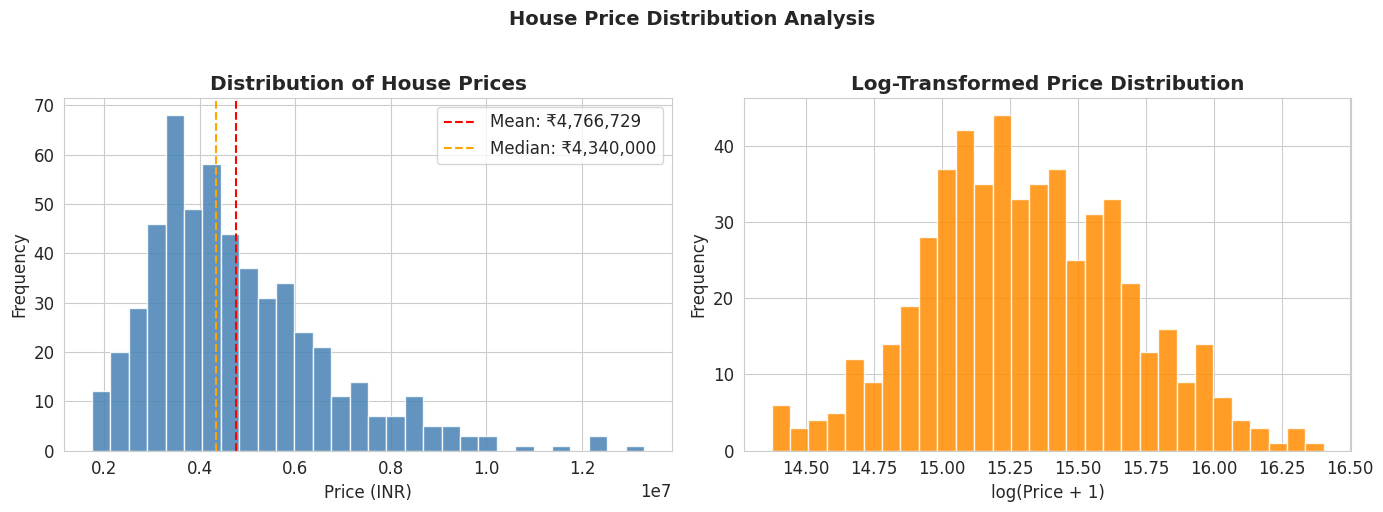

In [ ]:
# ── Distribution of target variable ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['price'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of House Prices', fontweight='bold')
axes[0].set_xlabel('Price (INR)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['price'].mean(), color='red', linestyle='--', label=f'Mean: ₹{df["price"].mean():,.0f}')
axes[0].axvline(df['price'].median(), color='orange', linestyle='--', label=f'Median: ₹{df["price"].median():,.0f}')
axes[0].legend()

# Log-scale distribution
axes[1].hist(np.log1p(df['price']), bins=30, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_title('Log-Transformed Price Distribution', fontweight='bold')
axes[1].set_xlabel('log(Price + 1)')
axes[1].set_ylabel('Frequency')

plt.suptitle('House Price Distribution Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 12.2 Histograms of All Features


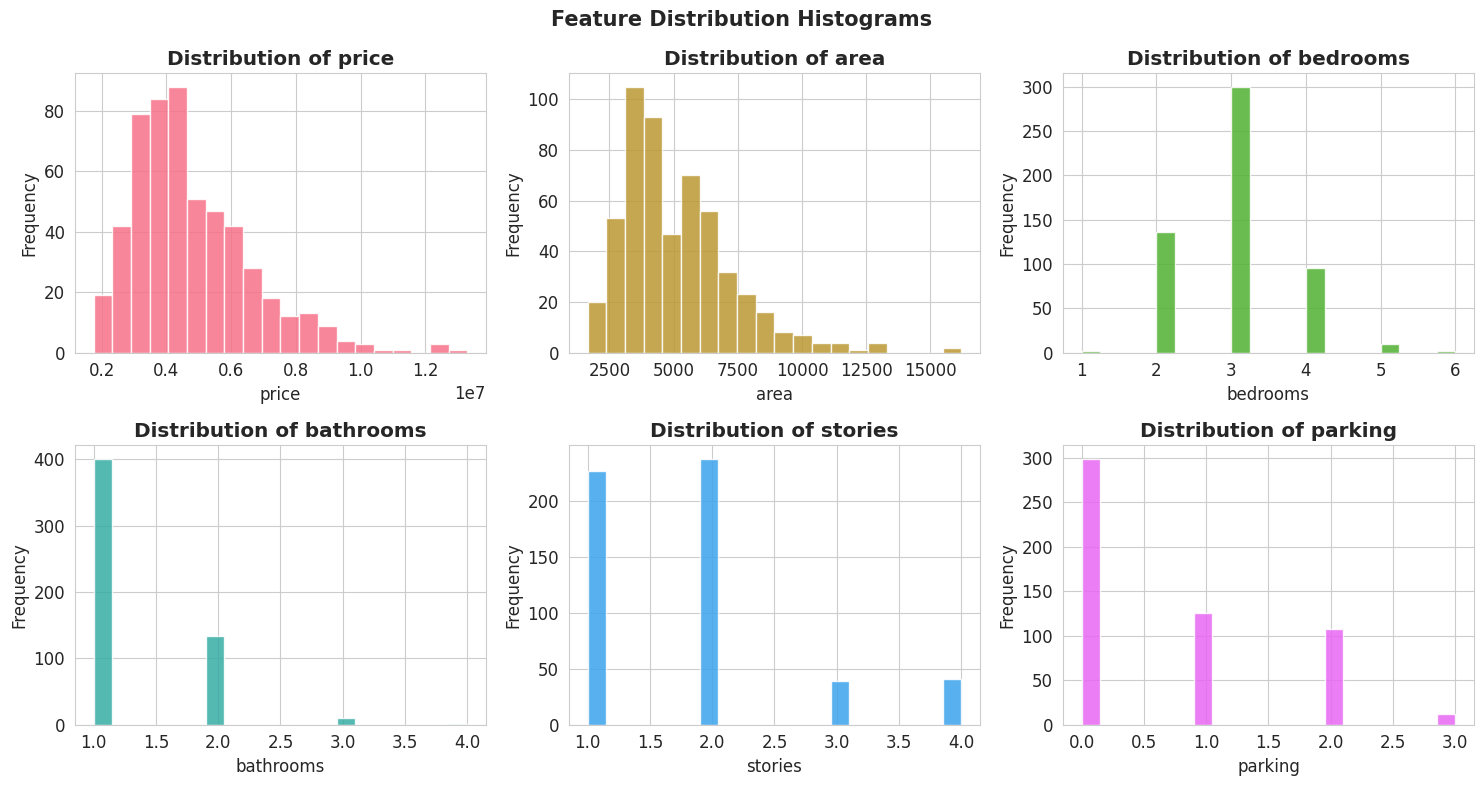

In [ ]:
# ── Histograms for all numeric features ──────────────────────────────────────
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=20, color=sns.color_palette('husl', len(numeric_cols))[i],
                 edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Feature Distribution Histograms', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


### 12.3 Box Plots – Outlier Visualization

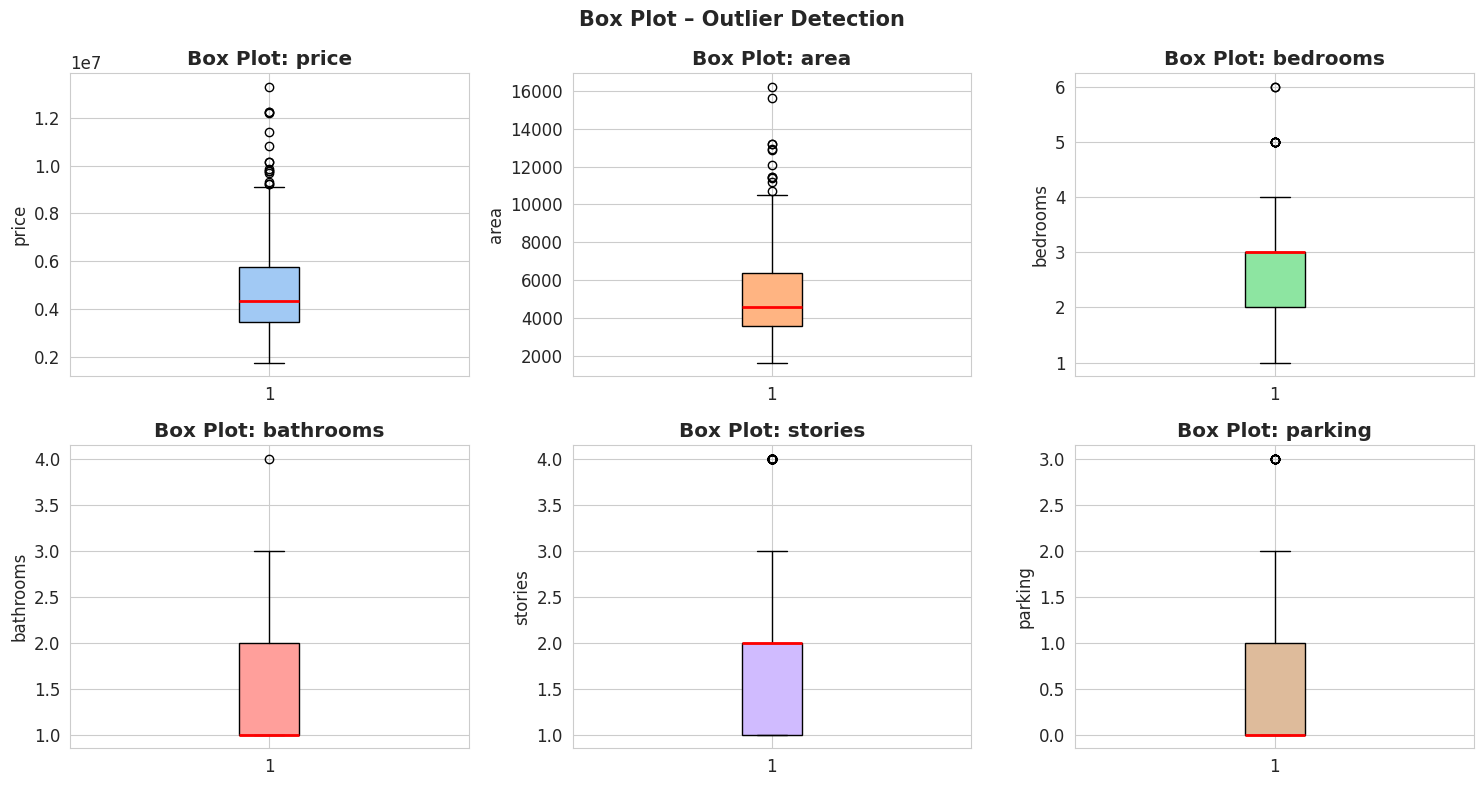

In [ ]:
# ── Box plots for numerical features ─────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor=sns.color_palette('pastel')[i % 6]),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'Box Plot: {col}', fontweight='bold')
    axes[i].set_ylabel(col)

plt.suptitle('Box Plot – Outlier Detection', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


### 12.4 Scatter Plots – Feature vs. Price

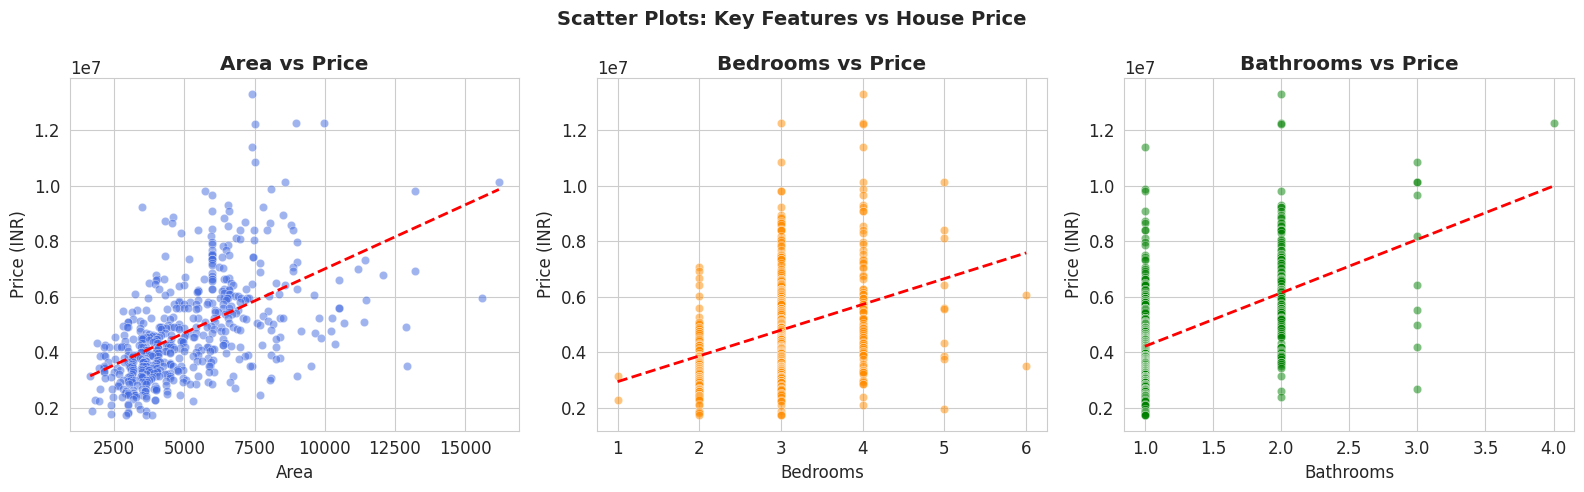

In [ ]:
# ── Scatter plots: each feature vs. price ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

scatter_features = ['area', 'bedrooms', 'bathrooms']
colors = ['royalblue', 'darkorange', 'green']

for ax, col, color in zip(axes, scatter_features, colors):
    ax.scatter(df[col], df['price'], alpha=0.5, color=color, edgecolors='white', linewidth=0.4)
    # Regression line
    z = np.polyfit(df[col], df['price'], 1)
    p = np.poly1d(z)
    ax.plot(sorted(df[col]), p(sorted(df[col])), 'r--', linewidth=2)
    ax.set_xlabel(col.capitalize(), fontsize=12)
    ax.set_ylabel('Price (INR)', fontsize=12)
    ax.set_title(f'{col.capitalize()} vs Price', fontweight='bold')

plt.suptitle('Scatter Plots: Key Features vs House Price', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 12.5 Pair Plot

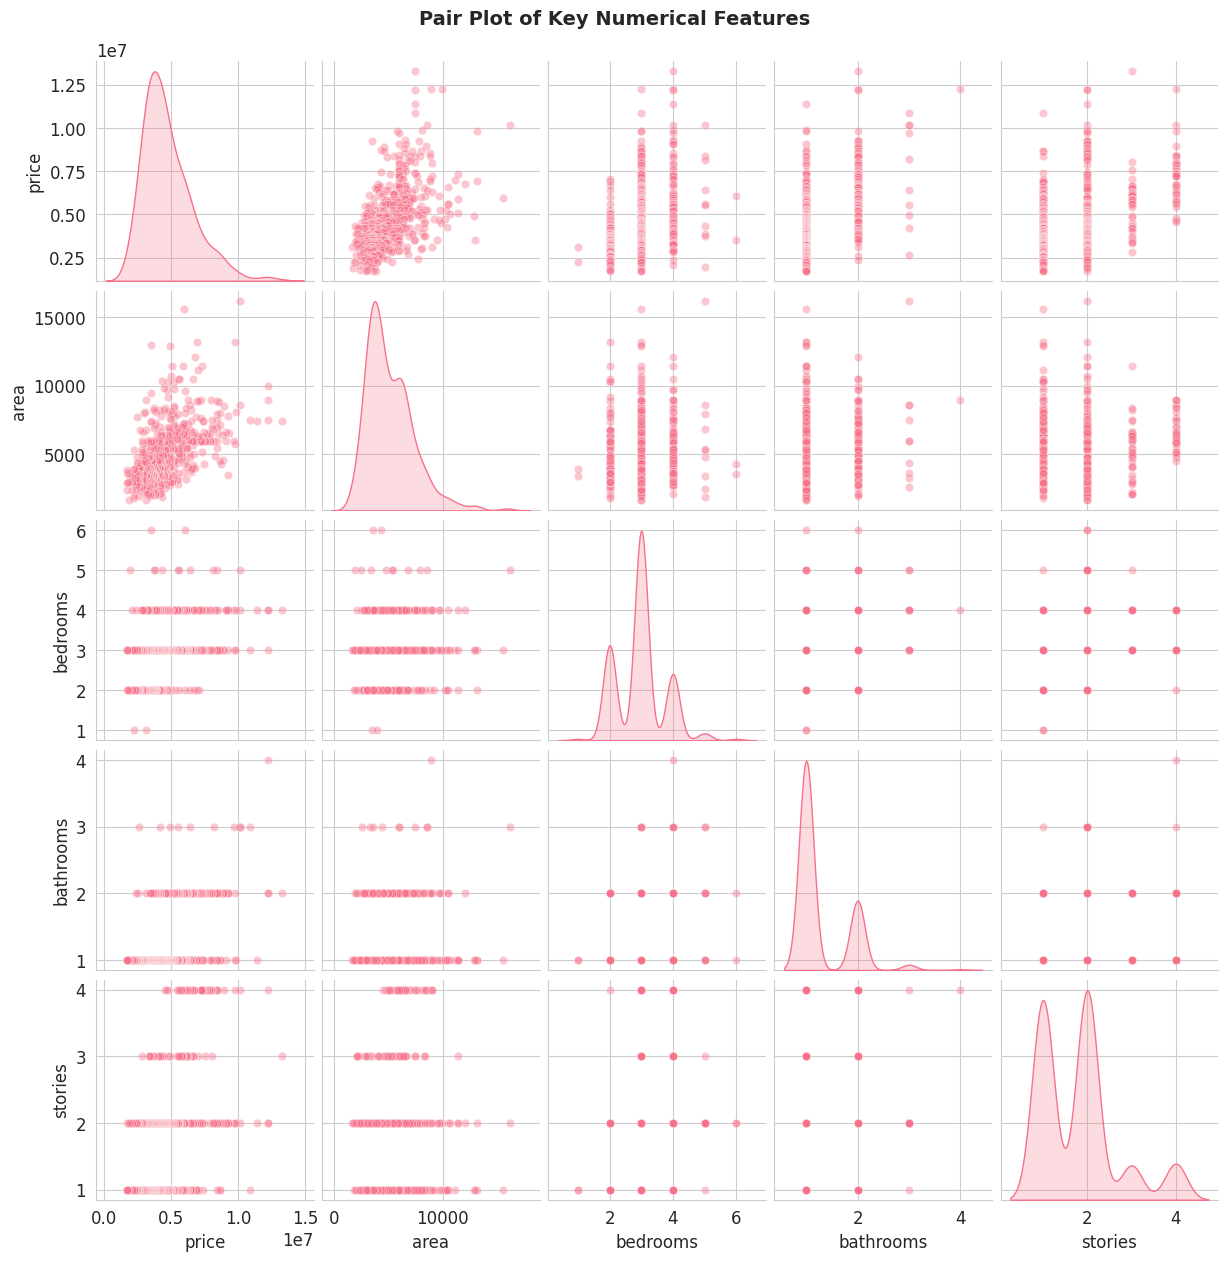

In [ ]:
# ── Pair plot for numerical features (sample for speed) ──────────────────────
pair_cols = ['price', 'area', 'bedrooms', 'bathrooms', 'stories']
sns.pairplot(df[pair_cols], diag_kind='kde', plot_kws={'alpha': 0.4})
plt.suptitle('Pair Plot of Key Numerical Features', y=1.01, fontsize=14, fontweight='bold')
plt.show()


### 12.6 Categorical Feature Analysis

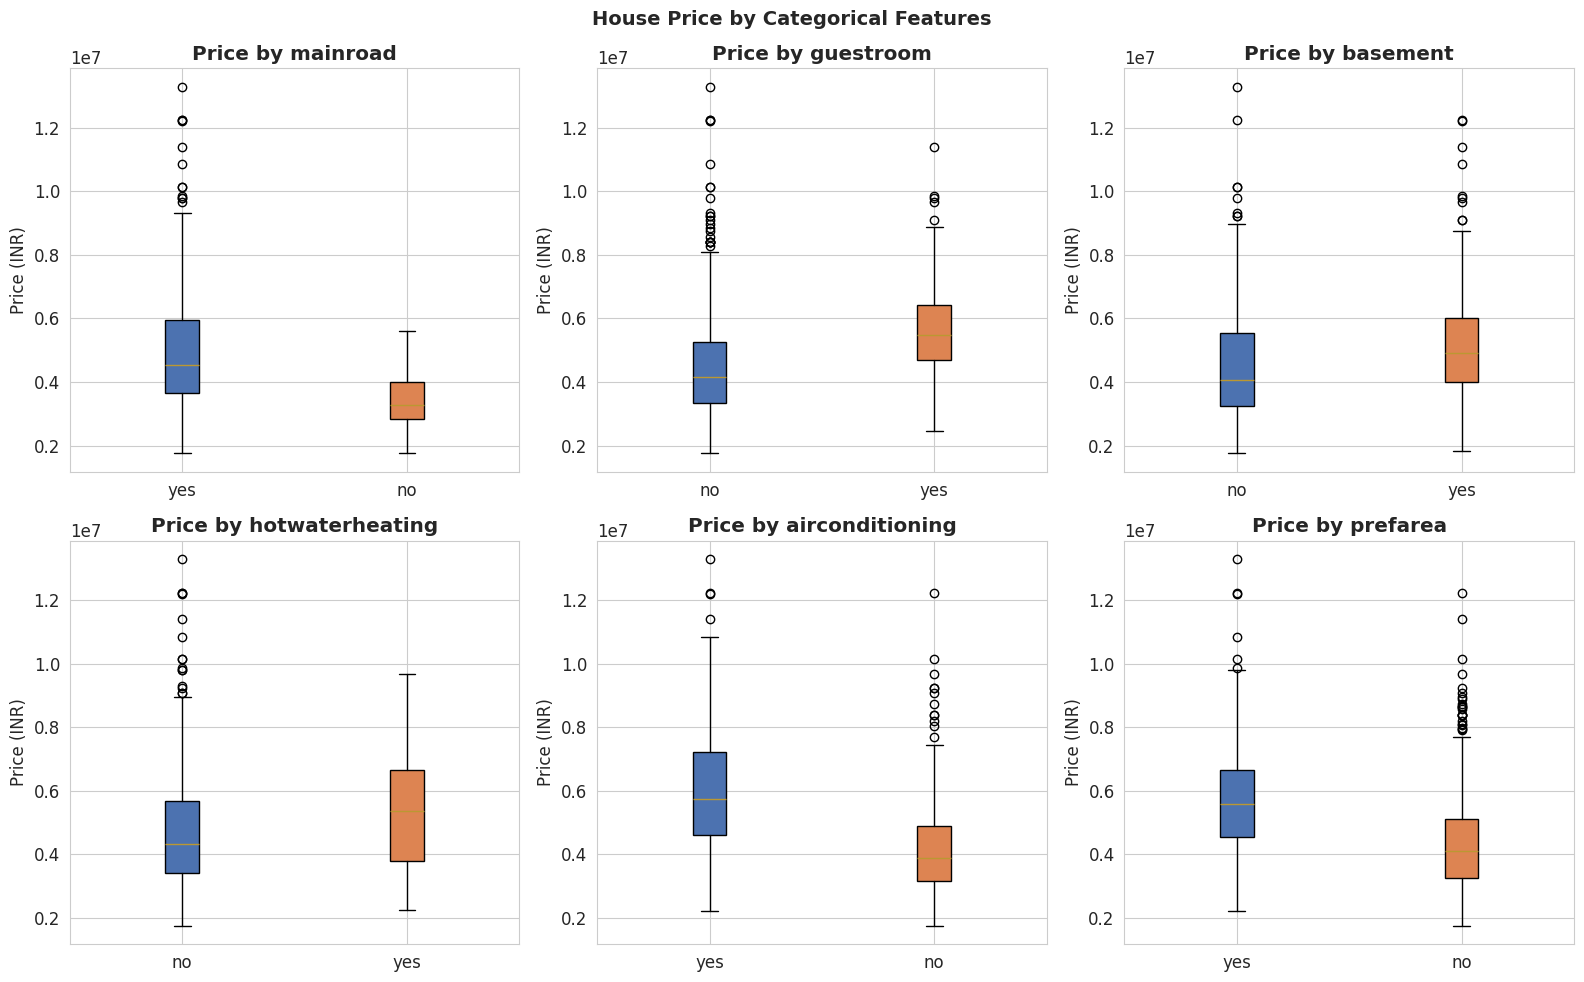

In [ ]:
# ── Price by categorical features ────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

cat_features = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

for i, col in enumerate(cat_features):
    groups = [df[df[col] == val]['price'].values for val in df[col].unique()]
    labels = df[col].unique()
    ax = axes[i]
    bp = ax.boxplot(groups, patch_artist=True, labels=labels)
    colors_bp = ['#4C72B0', '#DD8452']
    for patch, color in zip(bp['boxes'], colors_bp):
        patch.set_facecolor(color)
    ax.set_title(f'Price by {col}', fontweight='bold')
    ax.set_ylabel('Price (INR)')

plt.suptitle('House Price by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 12.7 Furnishing Status vs. Price

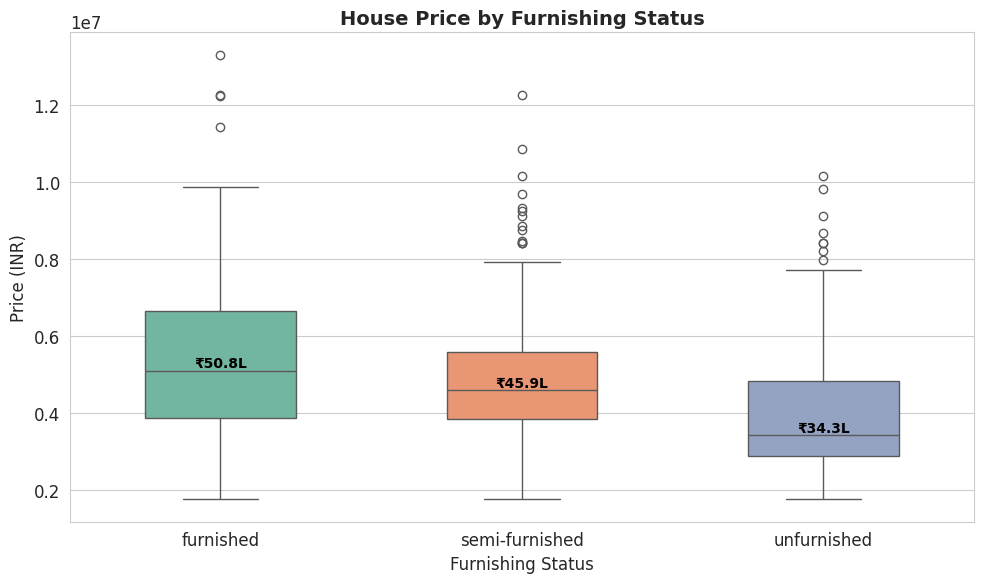

In [ ]:
# ── Furnishing status comparison ─────────────────────────────────────────────
plt.figure(figsize=(10, 6))
order = ['furnished', 'semi-furnished', 'unfurnished']
sns.boxplot(x='furnishingstatus', y='price', data=df, order=order,
            palette='Set2', width=0.5)
plt.title('House Price by Furnishing Status', fontsize=14, fontweight='bold')
plt.xlabel('Furnishing Status', fontsize=12)
plt.ylabel('Price (INR)', fontsize=12)

# Add median labels
for i, status in enumerate(order):
    median = df[df['furnishingstatus'] == status]['price'].median()
    plt.text(i, median * 1.02, f'₹{median/1e5:.1f}L', ha='center',
             fontsize=10, color='black', fontweight='bold')

plt.tight_layout()
plt.show()


## 🤖 Section 13: Machine Learning Models

### Helper: Evaluation Function

In [ ]:
# ── Evaluation function ──────────────────────────────────────────────────────
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, scaled=False):
    """Train model, compute metrics, return results dict."""
    Xtr = X_tr if not scaled else X_train_scaled
    Xte = X_te if not scaled else X_test_scaled

    model.fit(Xtr, y_tr)
    y_pred = model.predict(Xte)

    mae  = mean_absolute_error(y_te, y_pred)
    mse  = mean_squared_error(y_te, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_te, y_pred)
    cv   = cross_val_score(model, Xtr, y_tr, cv=5, scoring='r2').mean()

    results = {'Model': name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R²': r2, 'CV R²': cv}
    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  MAE  : ₹{mae:,.0f}")
    print(f"  RMSE : ₹{rmse:,.0f}")
    print(f"  R²   : {r2:.4f}")
    print(f"  CV R²: {cv:.4f}")
    return results, model, y_pred

all_results = []
all_predictions = {}


### 13.1 Linear Regression

In [ ]:
# ── Linear Regression ────────────────────────────────────────────────────────
lr = LinearRegression()
res_lr, lr_model, pred_lr = evaluate_model(
    'Linear Regression', lr, X_train, X_test, y_train, y_test, scaled=True
)
all_results.append(res_lr)
all_predictions['Linear Regression'] = pred_lr


  Linear Regression
  MAE  : ₹970,043
  RMSE : ₹1,324,507
  R²   : 0.6529
  CV R²: 0.6470


13.2 Decision Tree Regressor

In [ ]:
# ── Decision Tree Regressor ───────────────────────────────────────────────────
dt = DecisionTreeRegressor(random_state=42, max_depth=6)
res_dt, dt_model, pred_dt = evaluate_model(
    'Decision Tree', dt, X_train, X_test, y_train, y_test
)
all_results.append(res_dt)
all_predictions['Decision Tree'] = pred_dt


  Decision Tree
  MAE  : ₹1,226,190
  RMSE : ₹1,610,551
  R²   : 0.4868
  CV R²: 0.3278


### 13.3 Random Forest Regressor

In [ ]:
# ── Random Forest Regressor ───────────────────────────────────────────────────
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
res_rf, rf_model, pred_rf = evaluate_model(
    'Random Forest', rf, X_train, X_test, y_train, y_test
)
all_results.append(res_rf)
all_predictions['Random Forest'] = pred_rf


  Random Forest
  MAE  : ₹1,014,947
  RMSE : ₹1,399,769
  R²   : 0.6124
  CV R²: 0.5905


### 13.4 Gradient Boosting Regressor

In [ ]:
# ── Gradient Boosting Regressor ───────────────────────────────────────────────
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
res_gb, gb_model, pred_gb = evaluate_model(
    'Gradient Boosting', gb, X_train, X_test, y_train, y_test
)
all_results.append(res_gb)
all_predictions['Gradient Boosting'] = pred_gb


  Gradient Boosting
  MAE  : ₹969,168
  RMSE : ₹1,328,130
  R²   : 0.6510
  CV R²: 0.5534


### 13.5 XGBoost Regressor

In [ ]:
# ── XGBoost Regressor ─────────────────────────────────────────────────────────
if XGBOOST_AVAILABLE:
    xgb = XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=42,
                       verbosity=0, n_jobs=-1)
    res_xgb, xgb_model, pred_xgb = evaluate_model(
        'XGBoost', xgb, X_train, X_test, y_train, y_test
    )
    all_results.append(res_xgb)
    all_predictions['XGBoost'] = pred_xgb
else:
    print("XGBoost not available. Install with: !pip install xgboost")


  XGBoost
  MAE  : ₹1,065,928
  RMSE : ₹1,455,174
  R²   : 0.5811
  CV R²: 0.5603


## 📊 Section 14: Model Evaluation & Comparison

In [ ]:
# ── Model Comparison Table ────────────────────────────────────────────────────
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('R²', ascending=False).reset_index(drop=True)

print("MODEL PERFORMANCE COMPARISON")
print("=" * 80)
display(results_df.style
        .background_gradient(subset=['R²', 'CV R²'], cmap='Greens')
        .background_gradient(subset=['MAE', 'RMSE'], cmap='Reds_r')
        .format({'MAE': '₹{:,.0f}', 'MSE': '{:.2e}', 'RMSE': '₹{:,.0f}',
                 'R²': '{:.4f}', 'CV R²': '{:.4f}'})
       )

# ── Best model ────────────────────────────────────────────────────────────────
best_model_name = results_df.iloc[0]['Model']
print(f"\n🏆 Best Model: {best_model_name} (R² = {results_df.iloc[0]['R²']:.4f})")


MODEL PERFORMANCE COMPARISON


,Model,MAE,MSE,RMSE,R²,CV R²
0,Linear Regression,"₹970,043",1.75e+12,"₹1,324,507",0.6529,0.6470
1,Gradient Boosting,"₹969,168",1.76e+12,"₹1,328,130",0.6510,0.5534
2,Random Forest,"₹1,014,947",1.96e+12,"₹1,399,769",0.6124,0.5905
3,XGBoost,"₹1,065,928",2.12e+12,"₹1,455,174",0.5811,0.5603
4,Decision Tree,"₹1,226,190",2.59e+12,"₹1,610,551",0.4868,0.3278



🏆 Best Model: Linear Regression (R² = 0.6529)


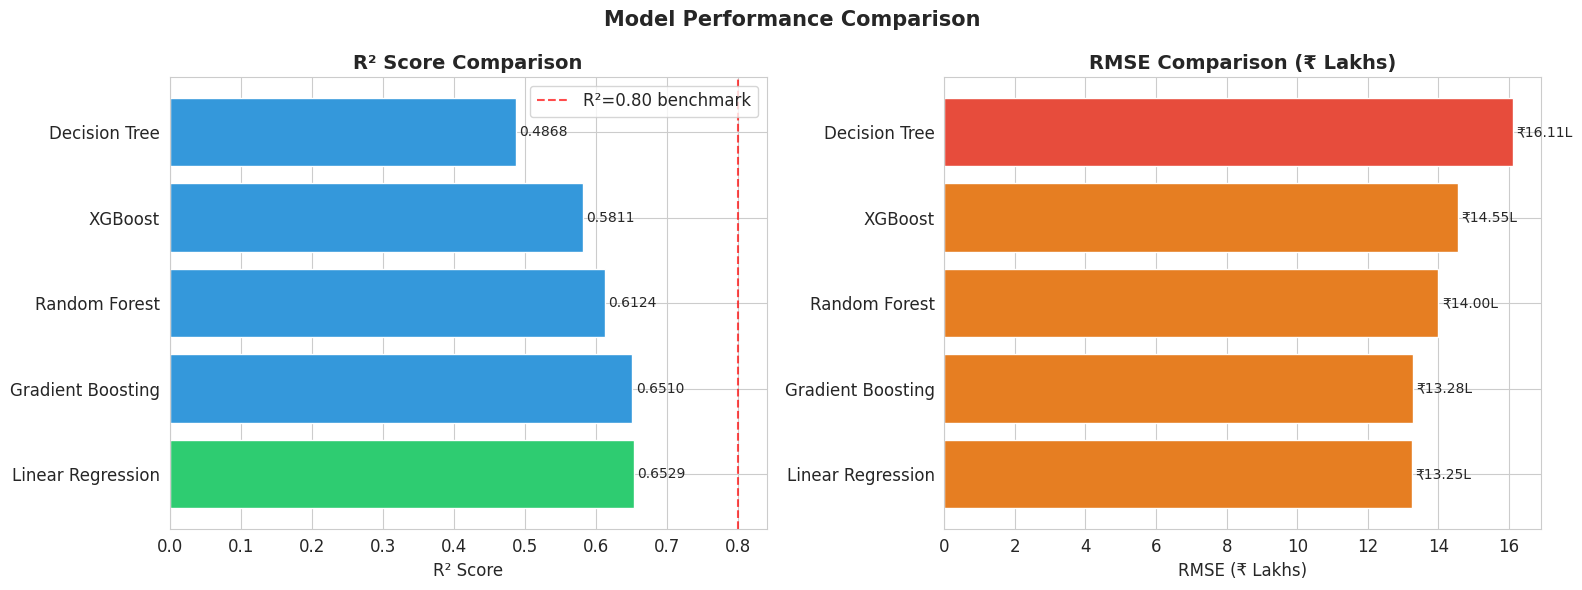

In [ ]:
# ── R² Score Comparison Bar Chart ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R² Comparison
colors_bar = ['#2ecc71' if r == results_df.iloc[0]['R²'] else '#3498db'
              for r in results_df['R²']]
axes[0].barh(results_df['Model'], results_df['R²'], color=colors_bar, edgecolor='white')
axes[0].set_title('R² Score Comparison', fontsize=14, fontweight='bold')
axes[0].set_xlabel('R² Score')
axes[0].axvline(0.8, color='red', linestyle='--', alpha=0.7, label='R²=0.80 benchmark')
axes[0].legend()
for i, (v, name) in enumerate(zip(results_df['R²'], results_df['Model'])):
    axes[0].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=10)

# RMSE Comparison
axes[1].barh(results_df['Model'], results_df['RMSE'] / 1e5,
             color=['#e74c3c' if r == results_df.iloc[-1]['RMSE'] else '#e67e22'
                    for r in results_df['RMSE']],
             edgecolor='white')
axes[1].set_title('RMSE Comparison (₹ Lakhs)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('RMSE (₹ Lakhs)')
for i, v in enumerate(results_df['RMSE'] / 1e5):
    axes[1].text(v + 0.1, i, f'₹{v:.2f}L', va='center', fontsize=10)

plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


**Explanation:** The bar charts clearly show that ensemble models (Random Forest, Gradient Boosting, XGBoost) outperform simpler models (Linear Regression, Decision Tree) in both R² and RMSE. The green bar highlights the best-performing model.

## ⚙️ Section 15: Hyperparameter Tuning

In [ ]:
# ── GridSearchCV on Random Forest ─────────────────────────────────────────────
print("Running GridSearchCV... (this may take a few minutes)")

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f"\n✅ GridSearchCV Complete")
print(f"Best Parameters : {grid_search.best_params_}")
print(f"Best CV R²      : {grid_search.best_score_:.4f}")


Running GridSearchCV... (this may take a few minutes)
Fitting 3 folds for each of 72 candidates, totalling 216 fits

✅ GridSearchCV Complete
Best Parameters : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}
Best CV R²      : 0.6348


In [ ]:
# ── RandomizedSearchCV on Gradient Boosting ──────────────────────────────────
from scipy.stats import randint, uniform

param_dist = {
    'n_estimators': randint(100, 500),
    'learning_rate': uniform(0.01, 0.2),
    'max_depth': randint(3, 8),
    'subsample': uniform(0.6, 0.4),
    'min_samples_split': randint(2, 10)
}

random_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_dist,
    n_iter=30,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
random_search.fit(X_train, y_train)

print(f"\n✅ RandomizedSearchCV Complete")
print(f"Best Parameters : {random_search.best_params_}")
print(f"Best CV R²      : {random_search.best_score_:.4f}")


Fitting 3 folds for each of 30 candidates, totalling 90 fits

✅ RandomizedSearchCV Complete
Best Parameters : {'learning_rate': np.float64(0.01628583713734685), 'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 195, 'subsample': np.float64(0.878206434570451)}
Best CV R²      : 0.6129


In [ ]:
# ── Evaluate Best Tuned Model ─────────────────────────────────────────────────
best_tuned = grid_search.best_estimator_
y_pred_tuned = best_tuned.predict(X_test)

mae_t  = mean_absolute_error(y_test, y_pred_tuned)
rmse_t = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_t   = r2_score(y_test, y_pred_tuned)

print("TUNED RANDOM FOREST RESULTS")
print("=" * 40)
print(f"MAE  : ₹{mae_t:,.0f}")
print(f"RMSE : ₹{rmse_t:,.0f}")
print(f"R²   : {r2_t:.4f}")


TUNED RANDOM FOREST RESULTS
MAE  : ₹1,008,255
RMSE : ₹1,388,667
R²   : 0.6185


**Explanation:** `GridSearchCV` exhaustively searches a predefined parameter grid using 3-fold cross-validation. `RandomizedSearchCV` randomly samples parameter combinations — faster and often equally effective for large search spaces. The best model from GridSearchCV will be used as our final model.

## 💾 Section 16: Save Final Model

In [ ]:
# ── Save model with Pickle ────────────────────────────────────────────────────
final_model = best_tuned  # Best tuned Random Forest

with open('house_price_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)
print("✅ Model saved as 'house_price_model.pkl' (Pickle)")

# ── Save scaler ───────────────────────────────────────────────────────────────
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✅ Scaler saved as 'scaler.pkl'")

# ── Save model with Joblib ────────────────────────────────────────────────────
joblib.dump(final_model, 'house_price_model.joblib')
print("✅ Model saved as 'house_price_model.joblib' (Joblib)")

# ── Load and verify ───────────────────────────────────────────────────────────
loaded_model = joblib.load('house_price_model.joblib')
test_pred = loaded_model.predict(X_test[:3])
print(f"\n✅ Model loaded and verified. Sample predictions: {test_pred}")


✅ Model saved as 'house_price_model.pkl' (Pickle)
✅ Scaler saved as 'scaler.pkl'
✅ Model saved as 'house_price_model.joblib' (Joblib)

✅ Model loaded and verified. Sample predictions: [5198521.15740741 7079606.36563067 3690106.43096363]


**Explanation:** `pickle.dump()` serializes the Python object to a binary file. `joblib.dump()` is preferred for scikit-learn models as it is more efficient with large numpy arrays. Both the model and scaler must be saved for complete deployment.

## 🏡 Section 17: Interactive Prediction System

In [ ]:
# ── Feature columns used during training ─────────────────────────────────────
feature_columns = X.columns.tolist()
print("Feature columns:", feature_columns)


Feature columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# HOUSE PRICE PREDICTION SYSTEM
# ══════════════════════════════════════════════════════════════════════════════

def predict_house_price(area, bedrooms, bathrooms, stories, parking,
                        mainroad='yes', guestroom='no', basement='no',
                        hotwaterheating='no', airconditioning='yes',
                        prefarea='no', furnishingstatus='semi-furnished'):
    """
    Predict house price given input features.

    Parameters:
    -----------
    area             : int   – Built-up area (sq ft)
    bedrooms         : int   – Number of bedrooms
    bathrooms        : int   – Number of bathrooms
    stories          : int   – Number of stories
    parking          : int   – Parking spaces
    mainroad         : str   – 'yes' / 'no'
    guestroom        : str   – 'yes' / 'no'
    basement         : str   – 'yes' / 'no'
    hotwaterheating  : str   – 'yes' / 'no'
    airconditioning  : str   – 'yes' / 'no'
    prefarea         : str   – 'yes' / 'no'
    furnishingstatus : str   – 'furnished' / 'semi-furnished' / 'unfurnished'

    Returns:
    --------
    Predicted house price in INR
    """
    # ── Binary encoding ────────────────────────────────────────────────────────
    yn_map = {'yes': 1, 'no': 0}
    input_data = {
        'area'           : area,
        'bedrooms'       : bedrooms,
        'bathrooms'      : bathrooms,
        'stories'        : stories,
        'mainroad'       : yn_map[mainroad],
        'guestroom'      : yn_map[guestroom],
        'basement'       : yn_map[basement],
        'hotwaterheating': yn_map[hotwaterheating],
        'airconditioning': yn_map[airconditioning],
        'parking'        : parking,
        'prefarea'       : yn_map[prefarea],
        # One-hot for furnishingstatus (semi-furnished=1,0 | unfurnished=0,1 | furnished=0,0)
        'furnishingstatus_semi-furnished': 1 if furnishingstatus == 'semi-furnished' else 0,
        'furnishingstatus_unfurnished'   : 1 if furnishingstatus == 'unfurnished' else 0
    }

    input_df = pd.DataFrame([input_data])

    # Ensure column order matches training
    input_df = input_df.reindex(columns=feature_columns, fill_value=0)

    predicted_price = final_model.predict(input_df)[0]
    return predicted_price


# ══════════════════════════════════════════════════════════════════════════════
# ── TEST PREDICTION ────────────────────────────────────────────────────────────
# ══════════════════════════════════════════════════════════════════════════════

print("╔══════════════════════════════════════════════════════╗")
print("║         HOUSE PRICE PREDICTION SYSTEM               ║")
print("╠══════════════════════════════════════════════════════╣")

# Input values
area             = 4500     # square feet
bedrooms         = 3
bathrooms        = 2
stories          = 2
parking          = 1
mainroad         = 'yes'
guestroom        = 'no'
basement         = 'no'
hotwaterheating  = 'no'
airconditioning  = 'yes'
prefarea         = 'no'
furnishingstatus = 'semi-furnished'

predicted_price = predict_house_price(
    area, bedrooms, bathrooms, stories, parking,
    mainroad, guestroom, basement, hotwaterheating,
    airconditioning, prefarea, furnishingstatus
)

print(f"║  Area            : {area} sq ft")
print(f"║  Bedrooms        : {bedrooms}")
print(f"║  Bathrooms       : {bathrooms}")
print(f"║  Stories         : {stories}")
print(f"║  Parking         : {parking}")
print(f"║  Main Road       : {mainroad}")
print(f"║  Air Conditioning: {airconditioning}")
print(f"║  Preferred Area  : {prefarea}")
print(f"║  Furnishing      : {furnishingstatus}")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  💰 PREDICTED PRICE : ₹{predicted_price:,.0f}")
print(f"║  💰 PREDICTED PRICE : ₹{predicted_price/1e5:.2f} Lakhs")
print("╚══════════════════════════════════════════════════════╝")


╔══════════════════════════════════════════════════════╗
║         HOUSE PRICE PREDICTION SYSTEM               ║
╠══════════════════════════════════════════════════════╣
║  Area            : 4500 sq ft
║  Bedrooms        : 3
║  Bathrooms       : 2
║  Stories         : 2
║  Parking         : 1
║  Main Road       : yes
║  Air Conditioning: yes
║  Preferred Area  : no
║  Furnishing      : semi-furnished
╠══════════════════════════════════════════════════════╣
║  💰 PREDICTED PRICE : ₹5,949,872
║  💰 PREDICTED PRICE : ₹59.50 Lakhs
╚══════════════════════════════════════════════════════╝


**Explanation:** The prediction function maps user inputs to the encoded feature space used during model training. Binary yes/no inputs are mapped to 1/0. The furnishing status is one-hot encoded to match the training columns. The model returns the predicted price in INR.

## 📉 Section 18: Final Visualizations

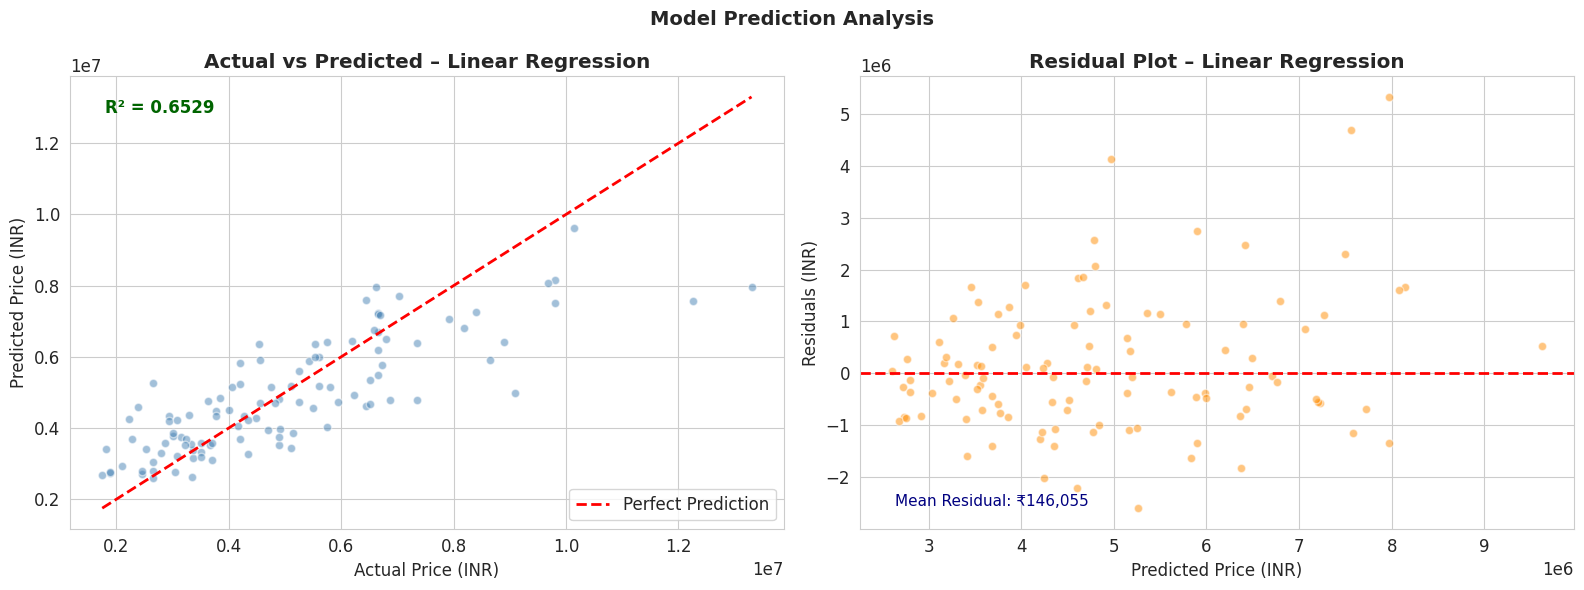

In [ ]:
# ── 1. Actual vs Predicted ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Use the best model's predictions
best_model_key = results_df.iloc[0]['Model']
y_pred_best = all_predictions[best_model_key]

axes[0].scatter(y_test, y_pred_best, alpha=0.5, color='steelblue', edgecolors='white')
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price (INR)', fontsize=12)
axes[0].set_ylabel('Predicted Price (INR)', fontsize=12)
axes[0].set_title(f'Actual vs Predicted – {best_model_key}', fontweight='bold')
axes[0].legend()

# R² annotation
r2 = r2_score(y_test, y_pred_best)
axes[0].annotate(f'R² = {r2:.4f}', xy=(0.05, 0.92), xycoords='axes fraction',
                 fontsize=12, color='darkgreen', fontweight='bold')

# ── 2. Residual Plot ───────────────────────────────────────────────────────────
residuals = y_test.values - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.5, color='darkorange', edgecolors='white')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Price (INR)', fontsize=12)
axes[1].set_ylabel('Residuals (INR)', fontsize=12)
axes[1].set_title(f'Residual Plot – {best_model_key}', fontweight='bold')
axes[1].annotate(f'Mean Residual: ₹{residuals.mean():,.0f}',
                 xy=(0.05, 0.05), xycoords='axes fraction', fontsize=11, color='navy')

plt.suptitle('Model Prediction Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


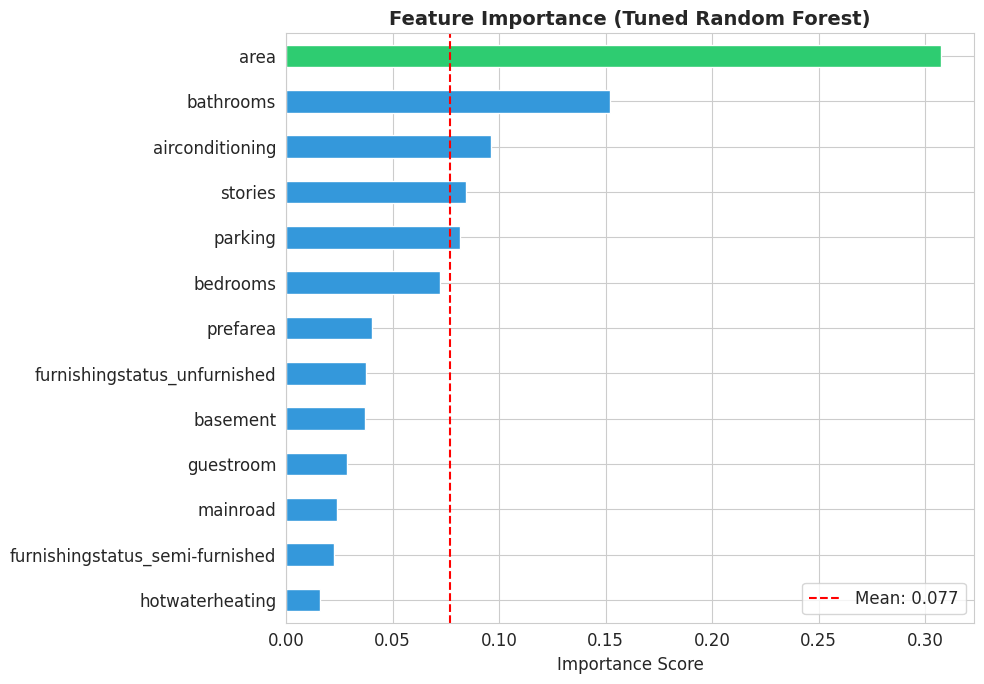


Top 5 Most Important Features:
area               0.307552
bathrooms          0.152178
airconditioning    0.096364
stories            0.084268
parking            0.081795


In [ ]:
# ── Feature Importance Plot (Random Forest) ───────────────────────────────────
rf_best = grid_search.best_estimator_
importance = pd.Series(rf_best.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=True)

plt.figure(figsize=(10, 7))
colors_fi = ['#2ecc71' if i == importance.index[-1] else '#3498db' for i in importance.index]
importance.plot(kind='barh', color=colors_fi, edgecolor='white')
plt.title('Feature Importance (Tuned Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.axvline(importance.mean(), color='red', linestyle='--', label=f'Mean: {importance.mean():.3f}')
plt.legend()
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
print(importance.sort_values(ascending=False).head(5).to_string())


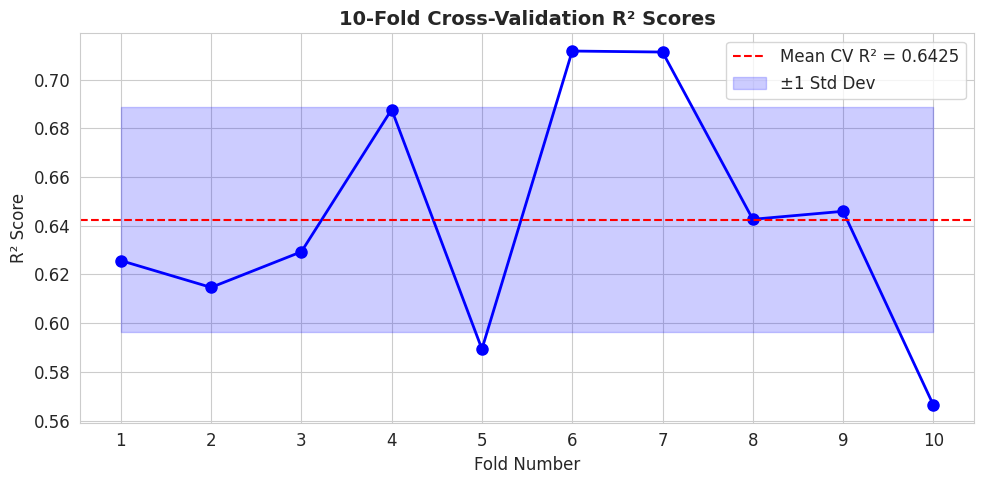


10-Fold CV Mean R² : 0.6425
10-Fold CV Std Dev : 0.0463


In [ ]:
# ── Cross-Validation Score Distribution ───────────────────────────────────────
cv_scores = cross_val_score(final_model, X_train, y_train, cv=10, scoring='r2')

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), cv_scores, 'bo-', markersize=8, linewidth=2)
plt.axhline(cv_scores.mean(), color='red', linestyle='--',
            label=f'Mean CV R² = {cv_scores.mean():.4f}')
plt.fill_between(range(1, 11),
                 cv_scores.mean() - cv_scores.std(),
                 cv_scores.mean() + cv_scores.std(),
                 alpha=0.2, color='blue', label='±1 Std Dev')
plt.title('10-Fold Cross-Validation R² Scores', fontsize=14, fontweight='bold')
plt.xlabel('Fold Number')
plt.ylabel('R² Score')
plt.xticks(range(1, 11))
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n10-Fold CV Mean R² : {cv_scores.mean():.4f}")
print(f"10-Fold CV Std Dev : {cv_scores.std():.4f}")
